In [1]:
import numpy as np
from numba import njit, prange
import jax
import jax.numpy as jnp
import mlx.core as mx

In [38]:
import numpy as np
from numba import njit, prange
import jax
import jax.numpy as jnp
import mlx.core as mx

x = np.random.rand(1000_000, 50)
x1 = np.random.rand(50, 1000_000)
y = - np.random.rand(1000_000)
y1 = - np.random.rand(1000_000).reshape(-1, 1)

print("Numba version:")
@njit(parallel=True, fastmath=True)
def calc_egm_numba(x, y):
    result = np.zeros((x.shape[1]))
    for i in prange(x.shape[1]):
        result[i] = np.sum(x[:, i] * y)
    return result


@njit(parallel=True, fastmath=True)
def calc_egm_numba_1(x, y):
    result = np.zeros((x.shape[0]))
    for i in prange(x.shape[0]):
        result[i] = np.sum(x[i, :] * y)
    return result

calc_egm_numba(x, y)  # Warm-up run to compile the function
calc_egm_numba_1(x1, y)  # Warm-up run to compile the function

%timeit calc_egm_numba(x, y)
%timeit calc_egm_numba_1(x1, y)

Numba version:
37.2 ms ± 1.77 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
2.47 ms ± 29.1 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
def calc_ecg_numba(lead_coords, tissue_coords, current_density):

    result = np.zeros((lead_coords.shape[1]))

    for i in range(lead_coords.shape[1]):
        d = np.linalg.norm(lead_coords[:, i])
        x = 1 / 
        result[i] = np.sum(x[:, i] * current_density)
    return result

In [39]:
print("Numpy version:")
%timeit np.sum(x * y[:, np.newaxis], axis=0)
%timeit np.sum(x1 * y[np.newaxis, :], axis=1)

Numpy version:
54.7 ms ± 691 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
38.3 ms ± 897 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [40]:
print("\nJAX version:")
@jax.jit
def calc_egm_jax(x, y):
    return jnp.sum(x * y[:, jnp.newaxis], axis=0)

@jax.jit
def calc_egm_jax_1(x, y):
    return jnp.sum(x * y[jnp.newaxis, :], axis=1)

x_jnp = jnp.array(x)
x1_jnp = jnp.array(x1)
y_jnp = jnp.array(y)

calc_egm_jax(x_jnp, y_jnp)  # Warm-up run to compile the function
calc_egm_jax_1(x1_jnp, y_jnp)  # Warm-up run to compile the function

%timeit calc_egm_jax(x_jnp, y_jnp)
%timeit calc_egm_jax_1(x1_jnp, y_jnp)


JAX version:
11.3 ms ± 146 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
7.72 ms ± 438 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
lead_coords = np.random.rand(3, 100)
tissue_coords = np.random.rand(3, 1000_000)
current_density = np.random.rand(1000_000)

lead_coords_jnp = jnp.array(lead_coords)
tissue_coords_jnp = jnp.array(tissue_coords)
current_density_jnp = jnp.array(current_density)


@jax.jit
def calc_ecg_jax(lead_coords, tissue_coords, current_density):

    def compute_single_lead(single_lead):
        d_single = jnp.linalg.norm(single_lead[:, jnp.newaxis] - tissue_coords, axis=0) # [N]
        x_single = 1.0 / d_single # [N]
        
        return jnp.dot(x_single, current_density) # Scalar

    calc_all_leads = jax.vmap(compute_single_lead, in_axes=(1,))
    
    # Returns an array of shape [M], never instantiating the full [M, N] grid
    return calc_all_leads(lead_coords)


calc_ecg_jax(lead_coords_jnp, tissue_coords_jnp, current_density_jnp) 

%timeit calc_ecg_jax(lead_coords_jnp, tissue_coords_jnp, current_density_jnp)
    

20.3 ms ± 283 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [42]:
print("\nMLX version:")

@mx.compile
def calc_egm_mlx(x, y):
    result = mx.sum(x * y[:, mx.newaxis], axis=0)
    return result


@mx.compile
def calc_egm_mlx_1(x, y):
    result = mx.sum(x * y[mx.newaxis, :], axis=1)
    return result

x_mx = mx.array(x)
x1_mx = mx.array(x1)
y_mx = mx.array(y)

calc_egm_mlx(x_mx, y_mx)  # Warm-up run to compile the function
calc_egm_mlx_1(x1_mx, y_mx)  #Warm-up run to compile the function

%timeit calc_egm_mlx(x_mx, y_mx)
%timeit calc_egm_mlx_1(x1_mx, y_mx)


MLX version:
1.71 μs ± 70.3 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
1.71 μs ± 70.5 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [16]:
def test_mlx_norm(x):
    res = mx.linalg.norm(x)
    mx.eval(res)
    return res


test_mlx_norm(tissue_coords_mlx)  # Warm-up run to compile the function

%timeit test_mlx_norm(tissue_coords_mlx)  # Warm-up run to compile the function

276 μs ± 1.77 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [ ]:
import mlx.core as mx


def calc_ecg_mlx(lead_coords, tissue_coords, current_density):
    
    def calc_signle_ecg_mlx(lead, tissue_coords, current_density):
        diff = lead[:, None] - tissue_coords
        d_single = mx.linalg.norm(diff, axis=0)
        d_single = mx.where(d_single == 0, 1, d_single)  # Avoid division by zero
        x_single = 1.0 / d_single
        return mx.sum(x_single * current_density)
    
    calc_all_leads = mx.vmap(calc_signle_ecg_mlx, in_axes=(1, None, None))

    return calc_all_leads(lead_coords, tissue_coords, current_density)


calc_ecg_mlx_optimized = mx.compile(calc_ecg_mlx)

def test_calc_ecg_mlx(lead_coords, tissue_coords, current_density):
    res = calc_ecg_mlx_optimized(lead_coords, tissue_coords, current_density)  # Warm-up run to compile the function
    mx.eval(res)
    return res


lead_coords_mlx = mx.array(lead_coords)
tissue_coords_mlx = mx.array(tissue_coords)
current_density_mlx = mx.array(current_density)

test_calc_ecg_mlx(lead_coords_mlx, tissue_coords_mlx, current_density_mlx)  # Warm-up run to compile the function

%timeit test_calc_ecg_mlx(lead_coords_mlx, tissue_coords_mlx, current_density_mlx)  # Warm-up run to compile the function

18.5 ms ± 142 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [25]:
res = calc_egm_numba(x, y)
res_jax = np.array(calc_egm_jax(x_jnp, y_jnp))
res_mlx = np.array(calc_egm_mlx(x_mx, y_mx))

np.allclose(res, res_jax, rtol=1e-5, atol=1e-8)
np.allclose(res, res_mlx, rtol=1e-5, atol=1e-8)

True

# EGM tracker

# Run 2D simulation

Running LuoRudy91 on [100, 20] Grid:   0%|          | 0/8000 [00:00<?, ?it/s]

Running LuoRudy91 on [100, 20] Grid: 100%|██████████| 8000/8000 [00:02<00:00, 3550.39it/s]


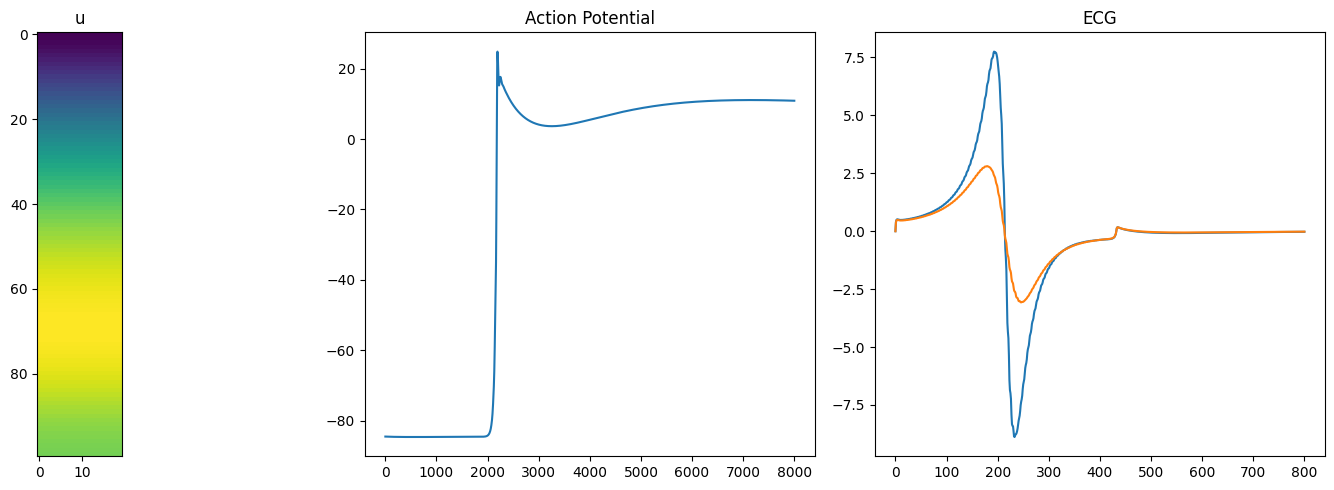

In [2]:
import matplotlib.pyplot as plt

import finitewave as fw
import numpy as np

# create a tissue of size 400x400 with cardiomycytes:
n = 100
m = 20
tissue = fw.CardiacTissue([n, m], dr=0.25)
tissue.mesh += (np.random.rand(n, m) < 0.0).astype(int)

stim_collection = fw.StimVoltageCoord(
    time=0,
    volt_value=1.0,
    x_min=0,
    x_max=1,
    y_min=0,
    y_max=n,
)

stim_sequence = fw.StimSequence()
stim_sequence.add_stim(stim_collection)

ap_tracker = fw.ActionPotentialTracker()
ap_tracker.node_inds = (n//2, m//2)
ap_tracker.start_time = 0.0

ecg_tracker = fw.EGMTracker()
ecg_tracker.start_time = 0.0
ecg_tracker.lead_coords = [(n//2, m//2, 5),
                           (n//2, m//2, 10),]
ecg_tracker.step = 10


tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(ap_tracker)
tracker_sequence.add_tracker(ecg_tracker)

# create model object and set up parameters:
simulation = fw.CardiacSimulation(backend="numba")
simulation.dt = 0.01
simulation.t_max = 80
simulation.cardiac_model = fw.LuoRudy91()
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence
simulation.tracker_sequence = tracker_sequence

# run the model:
simulation.run()

voltage_list = ap_tracker.output[:]

# plt.figure()
# plt.imshow(simulation.diffusion_model.weights[0].toarray())
# plt.show()

# show the potential map at the end of calculations:
%matplotlib inline
fig, axs = plt.subplots(ncols=3, figsize=(15, 5))
axs[0].imshow(simulation.cardiac_model["u"])
axs[0].set_title("u")
axs[1].plot(ap_tracker.output)
axs[1].set_title("Action Potential")
axs[2].plot(ecg_tracker.output)
axs[2].set_title("ECG")
plt.tight_layout()
plt.show()


Running AlievPanfilov on [100, 200] Grid: 100%|█████████▉| 3999/4000 [00:01<00:00, 2655.74it/s]


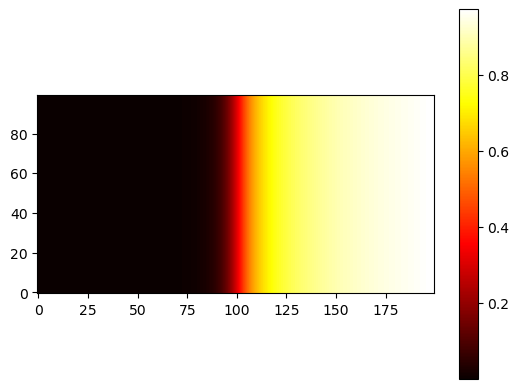

In [2]:
import matplotlib.pyplot as plt

import finitewave as fw
import numpy as np

# create a tissue of size 400x400 with cardiomycytes:
n = 100
m = 200
tissue = fw.CardiacTissue([n, m])
# tissue.mesh += (np.random.random(tissue.mesh.shape) < 0.2).astype(tissue.mesh.dtype)

# # set up stimulation parameters:
# stim = fw.StimVoltageCoord(time=0, volt_value=1,
#                            x_min=0, x_max=n,
#                            y_min=0, y_max=1)
# stim_collection = fw.StimVoltageCollection(start_time=0,
#                                            voltage_list=voltage_list,
#                                            duration=40)
# stim_collection.stimulation = stim

stim_collection = fw.StimCurrentCoord(
    time=0,
    curr_value=10.0,
    duration=.1,
    x_min=0,
    x_max=n,
    y_min=0,
    y_max=1,
)

stim_sequence = fw.StimSequence()
stim_sequence.add_stim(stim_collection)

diffusion_model = fw.GridAssembler()
diffusion_model.stencil = fw.IsotropicStencil()

egm_tracker = fw.ECGGridTracker([[n//2, 5, 1],
                                 [n//2, m//2, 1],
                                 [n//2, m-3, 1]],
                                 distance_power=2)
egm_tracker.start_time = 0.0


tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(egm_tracker)

# create model object and set up parameters:
simulation = fw.CardiacSimulation()
simulation.dt = 0.01
simulation.dr = 0.25
simulation.t_max = 40
simulation.cardiac_model = fw.AlievPanfilov()
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence
simulation.diffusion_model = diffusion_model
simulation.tracker_sequence = tracker_sequence

# run the model:
simulation.run()

# plt.figure()
# plt.imshow(simulation.diffusion_model.weights[0].toarray())
# plt.show()

# show the potential map at the end of calculations:
%matplotlib inline
plt.figure()
plt.imshow(simulation.cardiac_model.u, origin='lower', cmap='hot')
plt.colorbar()
plt.show()


Running AlievPanfilov on [100, 200] Grid: 100%|█████████▉| 1499/1501 [00:00<00:00, 9102.07it/s]


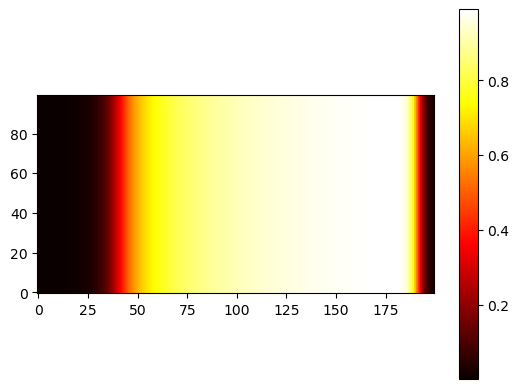

In [1]:
import matplotlib.pyplot as plt

import finitewave as fw
import numpy as np

# create a tissue of size 400x400 with cardiomycytes:
n = 100
m = 200
tissue = fw.CardiacTissue([n, m])
# tissue.mesh += (np.random.random(tissue.mesh.shape) < 0.2).astype(tissue.mesh.dtype)

# set up stimulation parameters:
stim = fw.StimVoltageCoord(time=0, volt_value=1,
                           x_min=0, x_max=n,
                           y_min=0, y_max=3)
stim_collection = fw.StimVoltageCollection(start_time=0,
                                           voltage_list=[1]*10,
                                           duration=0.09)
stim_collection.stimulation = stim

stim_sequence = fw.StimSequence()
stim_sequence.add_stim(stim_collection)

diffusion_model = fw.GridAssembler()
diffusion_model.stencil = fw.IsotropicStencil()

# create model object and set up parameters:
simulation = fw.CardiacSimulation()
simulation.dt = 0.01
simulation.dr = 0.25
simulation.t_max = 0.5
simulation.cardiac_model = fw.AlievPanfilov()
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence
simulation.diffusion_model = diffusion_model

# run the model:
simulation.run()
u_maps = []
u_maps.append(simulation.cardiac_model.u.copy())

simulation.t_max = 15
simulation.run(initialize=False)
u_maps.append(simulation.cardiac_model.u.copy())

simulation.t_max = 30
simulation.run(initialize=False)
u_maps.append(simulation.cardiac_model.u.copy())


# plt.figure()
# plt.imshow(simulation.diffusion_model.weights[0].toarray())
# plt.show()

# show the potential map at the end of calculations:
%matplotlib inline
plt.figure()
plt.imshow(simulation.cardiac_model.u, origin='lower', cmap='hot')
plt.colorbar()
plt.show()


In [3]:
def dr_model_to_mm(dr):
    cv_mm_ms = 0.6
    cv_model = 1.6 / 10
    # cv_model - dr
    # cv_mm_ms - res

    res = cv_mm_ms * dr / cv_model
    return res


def t_model_to_ms(t):
    return t * 10

dr = dr_model_to_mm(0.25)


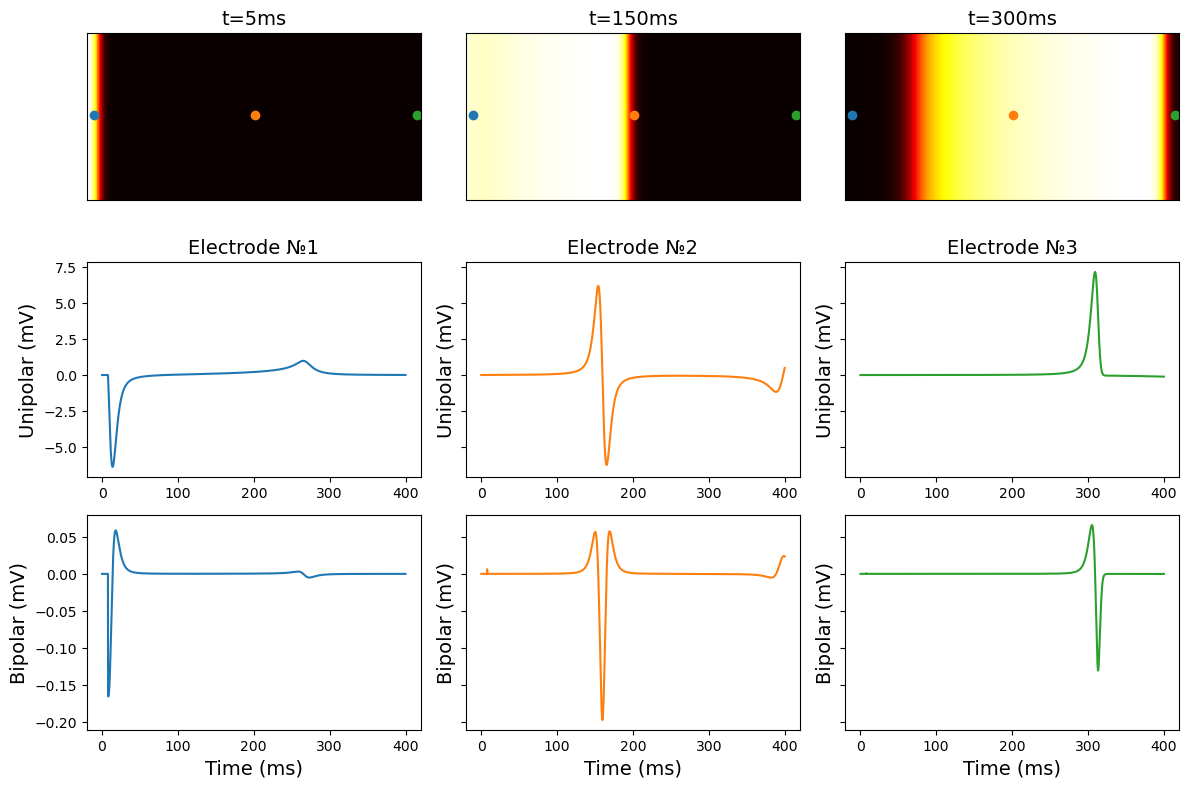

In [4]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'xtick.labelsize': 10,   # x-axis tick labels
    'ytick.labelsize': 10,   # y-axis tick labels
    'axes.labelsize': 14,    # axis labels (xlabel, ylabel)
    'axes.titlesize': 14,    # title size (optional)
    'figure.titlesize': 16,    # figure title size (optional)
    'lines.linewidth': 1.5
})


egm_points = np.array([[n//2, 3.5, 3], [n//2, m//2, 3], [n//2, m-3, 3]])

t_max = 40
t_list = [5, 150, 300]
egms = 100 / (4*np.pi) * egm_tracker.output * 0.25**2 / dr_model_to_mm(0.25) ** 2
egms[:79, :] = 0
# egms = egms[200:3400, :]
bi_egms = np.diff(egms, axis=0)
time_vector = np.arange(0, t_max, simulation.dt)[:] * 10

colors = ['tab:blue', 'tab:orange', 'tab:green']

%matplotlib inline
# make mosaic plot with potential map and EGM signals:
# first row: potential map
# second row: 3 plots with EGM signals
# third row: 3 plots with EGM signals' derivatives
fig, axs = plt.subplots(3, 3, figsize=(12, 8), sharex='row', sharey='row')
for i in range(3):
    axs[0, i].imshow(u_maps[i], origin='lower', cmap='hot')
    axs[0, i].set_title("t={:.0f}ms".format(t_list[i]))
    axs[0, i].scatter(egm_points[0, 1], egm_points[0, 0], color=colors[0])
    axs[0, i].scatter(egm_points[1, 1], egm_points[1, 0], color=colors[1])
    axs[0, i].scatter(egm_points[2, 1], egm_points[2, 0], color=colors[2])
    # axs[0, i].axis('off')
    axs[0, i].set_xticks([])
    axs[0, i].set_yticks([])
    axs[1, i].plot(time_vector, egms[:, i], color=colors[i])
    axs[1, i].set_title("Electrode №{}".format(i+1))
    # axs[1, i].set_xlabel("Time (ms)")
    axs[1, i].set_ylabel("Unipolar (mV)")
    axs[2, i].plot(time_vector[1:], bi_egms[:, i],
                   color=colors[i])
    # axs[2, i].set_title("Electrode №{}".format(i+1))
    axs[2, i].set_xlabel("Time (ms)")
    axs[2, i].set_ylabel("Bipolar (mV)")
plt.tight_layout()
plt.show()

In [94]:
fig.savefig("egm_signals.png", dpi=300)